# Part 0: Data Download and Cleaning


##  Data download and Verification

We first establish a local directory structure to store the NYC Yellow Taxi Trip Records  and include a conditional check to download the January 2024 dataset from a cloud source only if it is not already present on our system. By using the polars library for high-performance data loading, we set up the necessary environment to begin. NOTE: TO USE A CUSTOM PRECLEANED PARQUET SKIP TO THE CELL JUST ABOVE PART 1

In [10]:
import polars as pl
import pathlib as pathlb
from sklearn.preprocessing import StandardScaler, OneHotEncoder

file_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
base_dir = pathlb.Path('data/raw')
file_name = 'yellow_tripdata_2024-01.parquet'
file_path = base_dir/file_name
clean_path ='data/raw/cleaned_data.parquet'

## Checks if file downloaded if not it downloads it
if not file_path.is_file() :
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_parquet(file_url).write_parquet(file_path)
taxi_df = pl.read_parquet(file_path)



Next we verify our dataset's structure to ensure all necessary variables for Part 1 of the assignment are present. We define a target list of columns and check to identify any missing data 

In [11]:
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime','trip_distance','PULocationID', 'DOLocationID','fare_amount','tip_amount','payment_type']

try:
    # taxi_df should already be defined as a Polars DataFrame
    missing_cols = set(cols) - set(taxi_df.columns)

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("No missing columns.")
except Exception as e:
    print("Error while checking columns:", e)

print(f"{"SCHEMA"}\n")
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")

No missing columns.
SCHEMA

Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64


## Data Cleaning


### Cleaning Taxi Parquet

In this section, we conduct data cleaning, by removing records with null/NaN values, eliminate trips with invalid distances, and times

In [12]:
initial_rows = len(taxi_df)

# --- STEP 1: Nulls and NaNs ---
null_rows = initial_rows - taxi_df.filter(pl.all_horizontal(pl.col(cols).is_not_null())).height

taxi_df = taxi_df.filter(
    pl.all_horizontal(pl.col(cols).is_not_null()) &
    (~pl.col("fare_amount").is_nan()) & 
    (~pl.col("trip_distance").is_nan())
)
nan_rows = initial_rows - len(taxi_df) - null_rows

# --- STEP 2: Distance ---
pre_dist_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('trip_distance') > 0)
distance_rows = pre_dist_count - len(taxi_df)

# --- STEP 3: Fare ---
pre_fare_count = len(taxi_df)
taxi_df = taxi_df.filter((pl.col('fare_amount') > 0) & (pl.col('fare_amount') <= 500))
fare_rows = pre_fare_count - len(taxi_df)

# --- STEP 4: Time Duration ---
pre_time_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_dropoff_datetime') > pl.col('tpep_pickup_datetime'))
time_rows = pre_time_count - len(taxi_df)

# --- STEP 5: Year/Date Range ---
pre_year_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_pickup_datetime').dt.year() == 2024)
year_rows = pre_year_count - len(taxi_df)

removed_rows = initial_rows - len(taxi_df)

print(f"Initial rows:          {initial_rows:>10,}")
print(f"Null rows removed:     {null_rows:>10,}")
print(f"NaN rows removed:      {nan_rows:>10,}")
print(f"Zero distance removed: {distance_rows:>10,}")
print(f"Invalid fare removed:  {fare_rows:>10,}")
print(f"Invalid time removed:  {time_rows:>10,}")
print(f"Wrong year removed:    {year_rows:>10,}")
print(f"Total removed:         {removed_rows:>10,}")
print(f"Remaining rows:        {len(taxi_df):>10,}")

clean_path = 'data/cleaned_data.parquet'
import pathlib as pathlb
pathlb.Path('data').mkdir(parents=True, exist_ok=True)
taxi_df.write_parquet(clean_path)


Initial rows:           2,964,624
Null rows removed:              0
NaN rows removed:               0
Zero distance removed:     60,371
Invalid fare removed:      34,569
Invalid time removed:         112
Wrong year removed:            14
Total removed:             95,066
Remaining rows:         2,869,558


# Part 1: Data Preprocessing & Feature Engineering 


## Feature Engineering

In this section we use the cleaned dataset to generate features for the models we will be creating later

In [13]:
taxi_df = pl.read_parquet('data/cleaned_data.parquet')
display(taxi_df)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-01-31 23:45:59,2024-01-31 23:54:36,null,3.18,null,null,107,263,0,15.77,0.0,0.5,2.0,0.0,1.0,21.77,null,null
1,2024-01-31 23:13:07,2024-01-31 23:27:52,null,4.0,null,null,114,236,0,18.4,1.0,0.5,2.34,0.0,1.0,25.74,null,null
2,2024-01-31 23:19:00,2024-01-31 23:38:00,null,3.33,null,null,211,25,0,19.97,0.0,0.5,0.0,0.0,1.0,23.97,null,null


First we join obatin the look up table 

In [14]:
file_name ='lookup.csv'
file_path = base_dir / file_name
file_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not file_path.is_file():
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_csv(file_url,encoding="utf8-lossy").write_csv(file_path)

Next we explore the lookup table

In [15]:
lookup_df = pl.read_csv(file_path)
display(lookup_df)

LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""
…,…,…,…
261,"""Manhattan""","""World Trade Center""","""Yellow Zone"""
262,"""Manhattan""","""Yorkville East""","""Yellow Zone"""
263,"""Manhattan""","""Yorkville West""","""Yellow Zone"""


Now we check all the available Boroughs in the lookup dataframe

In [16]:
display(lookup_df.select(pl.col('Borough')).unique())

Borough
str
"""N/A"""
"""Unknown"""
"""Staten Island"""
"""Manhattan"""
"""Bronx"""
"""Brooklyn"""
"""EWR"""
"""Queens"""


Now we use the Borough names and join them to the associated pick up and drop off locations

In [17]:
# join pickup location to PULocationID
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "PU_Borough"})

#join dropoff location to DOLocationID
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "DO_Borough"})

# replace nulls with Unknown
taxi_df = taxi_df.with_columns([
    pl.col("PU_Borough").fill_null("Unknown"),
    pl.col("DO_Borough").fill_null("Unknown")
])


We add the temporal features; pickup_hour, pickup_day_of_week (numeric, 0 = Monday),is_weekend (boolean)

In [18]:
#Temporal features
taxi_df = taxi_df.with_columns( 
    #Create col that indexes pickup hour
    (pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour')),
    #Create col that indexes weekday, starting at 0
    (pl.col('tpep_pickup_datetime').dt.weekday()-1).alias('pickup_day_of_week')
    ).with_columns(
        # Creates boolean weekend col
        (pl.col('pickup_day_of_week') >= 5).alias('is_weekend')
        .cast(pl.Int8)
    )


We add the trip features: trip_duration_minutes, trip_speed_mph, log_trip_distance (log-
transformed distance)

In [19]:
#Trip Features
taxi_df  = taxi_df.with_columns(
    (pl.col('tpep_dropoff_datetime')- pl.col('tpep_pickup_datetime'))
    #Convert trip duration minutes distance to interger
    .dt.total_minutes().alias('trip_duration_minutes')
    ).with_columns(
        #accounts for zero denominator error
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('trip_distance')* 60/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if duration 0 -> just 0 mph
        .alias('trip_speed_mph')
    ).with_columns(
    pl.col('trip_distance').log1p().alias('log_trip_distance'))

We addthe Fare features: fare_per_mile (fare_amount / trip_distance, handle division by zero),
fare_per_minute (fare_amount / trip_duration_minutes)

In [20]:
#Fare Features
taxi_df = taxi_df.with_columns(
        pl.when(pl.col('trip_distance') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_distance')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_mile'),
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_minute')
        )


Next we observe the schema after the newly added features

In [21]:
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")


Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64
PU_Borough               String
DO_Borough               String
pickup_hour              Int8
pickup_day_of_week       Int8
is_weekend               Int8
trip_duration_minutes    Int64
trip_speed_mph           Float64
log_trip_distance        Float64
fare_per_mile            Float64
fare_p

We filter out all payments other than credit card payments as recommended

In [22]:
taxi_df = taxi_df.filter(pl.col("payment_type") == 1)

## Target Variable Creation 

Here we create our second target variable high_tip, using binary classification

In [23]:
taxi_df = taxi_df.with_columns([
    pl.col("tip_amount").cast(pl.Float64).alias("tip_amount"),
    (pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    #casts the boolean value to 1 or zero
    .cast(pl.Int8)
    .alias("high_tip")
])


Next we explore the distribution of our second target variable high_tip

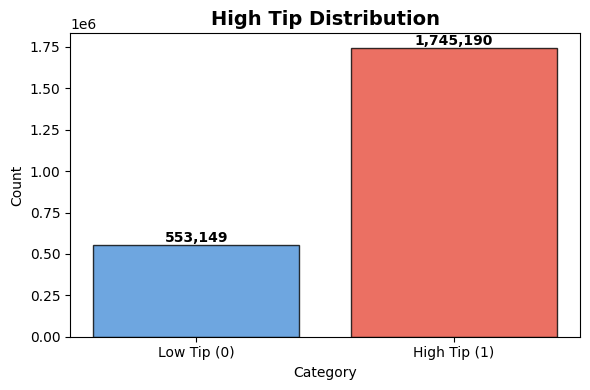

high_tip,count,proportions
i8,u32,f64
0,553149,0.240673
1,1745190,0.759327


In [24]:
import matplotlib.pyplot as plt


counts_df = (
    taxi_df.group_by("high_tip")
    .agg(pl.len().alias("count"))
    .sort("high_tip")
)

categories = ["Low Tip (0)", "High Tip (1)"]
counts = counts_df["count"].to_list()


fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, counts, color=['#4A90D9', '#E74C3C'], edgecolor='black', alpha=0.8)


ax.set_title('High Tip Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

for i, count in enumerate(counts):
    ax.text(i, count + (max(counts) * 0.01), f'{count:,}', 
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
# table showing distribution and proportion
display(taxi_df.group_by("high_tip").agg(pl.len().alias("count")).with_columns(proportions = pl.col("count") / pl.col("count").sum()))

## Data Splitting & Scaling

Next we categorize our variables to streamline our data by sby separating our data into numeric and catergorical features

In [25]:
numeric_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype.is_numeric()
]

categorical_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype == pl.String
]

Next we refine our list of numeric features by removing the target variables and identifiers to prevent data leakage and ensure model integrity

In [26]:
if 'tip_amount' in numeric_features: numeric_features.remove('tip_amount')
if 'high_tip' in numeric_features: numeric_features.remove('high_tip')
if "PULocationID" in numeric_features: numeric_features.remove("PULocationID")
if "DOLocationID" in numeric_features: numeric_features.remove("DOLocationID")
if "total_amount" in numeric_features: numeric_features.remove("total_amount")

We check our data for any empty entries. We first find any cells containing a "?" and turn them into official "null" values

In [27]:
taxi_df = taxi_df.with_columns(
    pl.all().map_batches(lambda s: s.replace("?", None) if s.dtype == pl.String else s)
)

total_rows = len(taxi_df)
missing_stats = (
    taxi_df.select([
        (pl.col(c).is_null().sum() / total_rows * 100).round(2).alias(c)
        for c in taxi_df.columns
    ])
    .melt(variable_name="column", value_name="missing_pct")
    .filter(pl.col("missing_pct") > 0)
)

total_affected = taxi_df.filter(pl.any_horizontal(pl.all().is_null())).height

cols = taxi_df.columns 

print("Missing value percentages:")
print(missing_stats)
print(f"\nTotal rows affected: {total_affected:,} ({(total_affected/total_rows*100):.1f}%)")

Missing value percentages:
shape: (0, 2)
┌────────┬─────────────┐
│ column ┆ missing_pct │
│ ---    ┆ ---         │
│ str    ┆ f64         │
╞════════╪═════════════╡
└────────┴─────────────┘

Total rows affected: 0 (0.0%)


/var/folders/yd/xx3gc_bd0y911x26fq021tgw0000gn/T/ipykernel_56333/1344606208.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="missing_pct")


we establish a pipeline to prepare our data for the machine learning models that ensure all information is in the correct format. We use a numeric pipeline to fill any missing data with the median value and scale the numbers so they are easier for our models to compare and  a categorical pipeline fills in missing words and converts text like borough names into numerical codes the computer can process

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# 1. Define the Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# 3. Build the Final Pipelines
# These will handle preprocessing AND modeling in one go
lr_reg = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
rf_reg = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))])
log_reg = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000))])
rf_clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))])

We then combine our individual processing lines into a single ColumnTransformer to ensure that our entire dataset is preprocessed in one coordinated step

In [29]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drops any columns we didn't explicitly include (like targets)
)

print(f'  Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')

  Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
  Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [30]:
to_exclude = ['tip_amount', 'high_tip', 'total_amount', 'PULocationID', 'DOLocationID']

numeric_features = [c for c in numeric_features if c not in to_exclude]
categorical_features = [c for c in categorical_features if c not in to_exclude]

print("FEATURE SUMMARY")
print(f"Numeric ({len(numeric_features)}): {numeric_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

print("EXCLUSIONS & REASONING")
all_cols = taxi_df.columns
for col in all_cols:
    if col not in numeric_features and col not in categorical_features and col != 'high_tip':

        if col in ['total_amount', 'tip_amount']:
            reason = "Data Leakage: Contains the answer we are trying to predict."
        elif "datetime" in col:
            reason = "Redundant: Replaced by engineered hour/day/weekend features."
        elif "ID" in col:
            reason = "Redundant: Replaced by more descriptive Borough names."
        else:
            reason = "Metadata/Administrative: Not predictive for this model."
        print(f"Excluded: {col:<25} Reason: {reason}")

FEATURE SUMMARY
Numeric (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']
EXCLUSIONS & REASONING
Excluded: tpep_pickup_datetime      Reason: Redundant: Replaced by engineered hour/day/weekend features.
Excluded: tpep_dropoff_datetime     Reason: Redundant: Replaced by engineered hour/day/weekend features.
Excluded: PULocationID              Reason: Redundant: Replaced by more descriptive Borough names.
Excluded: DOLocationID              Reason: Redundant: Replaced by more descriptive Borough names.
Excluded: tip_amount                Reason: Data Leakage: Contains the answer we are trying to predict.
Excluded: total_amount

# Part 2: Model Training & Tuning

In this section, we assemble the final machine learning pipeline by combining our data preprocessor with a Logistic Regression classifier

In [31]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Regression pipelines
lr_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# Classification pipelines
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])


We now divide the data into three subsets to ensure we can properly train the model and evaluate its performance. 

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define Features and Targets
X = taxi_df.select(numeric_features + categorical_features)
y_clf = taxi_df.select("high_tip").to_series().to_numpy()
y_reg = taxi_df.select("tip_amount").to_series().to_numpy()

# First Split: 70% Training, 30% Temporary (for Val/Test)
X_train, X_temp, y_train_clf, y_temp_clf, y_train_reg, y_temp_reg = train_test_split(
    X,
    y_clf,       # Classification Target (High Tip 0/1)
    y_reg,       # Regression Target (Tip Amount $)
    test_size=0.30,
    random_state=42,
    stratify=y_clf
)

# Second Split: Divide the 30% temporary set exactly in half (15% each)
X_val, X_test, y_val_clf, y_test_clf, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_clf, y_temp_reg,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_clf
)

# Apply Preprocessing — fit only on training data, then transform val/test
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)
X_test_transformed  = preprocessor.transform(X_test)

# Create a 25% training sample for hyperparameter search (faster tuning)
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train_reg,
    train_size=0.25,
    random_state=42
)

# Summary of split
def get_dist(labels):
    counts = np.bincount(labels.astype(int))
    low  = counts[0] if len(counts) > 0 else 0
    high = counts[1] if len(counts) > 1 else 0
    return f"{low:,} Low / {high:,} High ({(high/len(labels))*100:.2f}% High)"

print("--- Data Split & Stratification Summary ---")
print(f"{'Split Set':<15} | {'Row Count':<10} | {'Class Distribution (Target: high_tip)'}")
print("-" * 75)
print(f"{'Training':<15} | {len(y_train_clf):<10,} | {get_dist(y_train_clf)}")
print(f"{'Validation':<15} | {len(y_val_clf):<10,} | {get_dist(y_val_clf)}")
print(f"{'Testing':<15} | {len(y_test_clf):<10,} | {get_dist(y_test_clf)}")

print("\n--- Feature Transformation Summary ---")
print(f"Total Features Processed: {X_train_transformed.shape[1]}")
print(f"Numeric Features Scaled:  {len(numeric_features)}")
print(f"Categorical Features Encoded: {len(categorical_features)}")


--- Data Split & Stratification Summary ---
Split Set       | Row Count  | Class Distribution (Target: high_tip)
---------------------------------------------------------------------------
Training        | 1,608,837  | 387,204 Low / 1,221,633 High (75.93% High)
Validation      | 344,751    | 82,972 Low / 261,779 High (75.93% High)
Testing         | 344,751    | 82,973 Low / 261,778 High (75.93% High)

--- Feature Transformation Summary ---
Total Features Processed: 38
Numeric Features Scaled:  20
Categorical Features Encoded: 3


___

## Baseline Models

We now have structured a dual-pipeline approach to independently train and evaluate our regression models and will test them

In [33]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

print("Training Regression Models...")
start_lr = time.time()
lr_reg.fit(X_train, y_train_reg)
lr_time = time.time() - start_lr

start_rf = time.time()
rf_reg.fit(X_train, y_train_reg)
rf_time = time.time() - start_rf

def get_regression_metrics(model, X, y_true, name, duration):
    preds = model.predict(X)
    mae  = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2   = r2_score(y_true, preds)
    return {
        "Model":    name,
        "MAE":      f"{mae:.4f}",
        "RMSE":     f"{rmse:.4f}",
        "R^2":      f"{r2:.4f}",
        "Time (s)": f"{duration:.2f}s"
    }

lr_stats = get_regression_metrics(lr_reg, X_val, y_val_reg, "Linear Regression",  lr_time)
rf_stats = get_regression_metrics(rf_reg, X_val, y_val_reg, "Random Forest",       rf_time)

results_df = pd.DataFrame([lr_stats, rf_stats])
print("\nBaseline Regression Performance")
display(results_df)


Training Regression Models...

Baseline Regression Performance


,Model,MAE,RMSE,R^2,Time (s)
0,Linear Regression,1.2076,2.3079,0.6351,5.23s
1,Random Forest,1.1845,2.2848,0.6423,184.85s


After evaluation we find obtain R^2 values of 0.6351 and 0.6423 that indicate that we are successfully capturing a significant portion of the variance in tip amounts. We also observe that the MAE ranges from 1.1845 to 1.2076, representing the average units our predictions deviate from the actual values, while our higher RMSE values of 2.2848 and 2.3079 reveal that the models are affacted by large outlier errors.

In [34]:
print("Training Classification Models...")
log_reg.fit(X_train, y_train_clf)
rf_clf.fit(X_train, y_train_clf)

def get_classification_metrics(model, X, y_true, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] 
    
    return {
        "Model": name,
        "Accuracy": f"{accuracy_score(y_true, preds):.4f}",
        "Precision": f"{precision_score(y_true, preds):.4f}",
        "Recall": f"{recall_score(y_true, preds):.4f}",
        "F1-Score": f"{f1_score(y_true, preds):.4f}",
        "AUC-ROC": f"{roc_auc_score(y_true, probs):.4f}"
    }

log_stats = get_classification_metrics(log_reg, X_val, y_val_clf, "Logistic Regression")
rf_stats = get_classification_metrics(rf_clf, X_val, y_val_clf, "Random Forest Classifier")

results_clf_df = pd.DataFrame([log_stats, rf_stats])
print("\nBaseline Classification Performance")
display(results_clf_df)


Training Classification Models...

Baseline Classification Performance


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.7710,0.7691,0.9981,0.8687,0.6098
1,Random Forest Classifier,0.7712,0.7687,0.9995,0.8690,0.6194


After evaluation we obatined accuracy scores of 0.7710 and 0.7712 and the near-perfect recall scores. The AUC-ROC values of 0.6098 and 0.6194 are the most show the models are only performing slightly better than a random guess at actually separating high tips from low tip

____


In [35]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter space to search
param_dist = {
    'regressor__n_estimators':    [50, 100, 200],
    'regressor__max_depth':       [10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__bootstrap':       [True]
}

random_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print(f"Searching for best hyperparameters using a 25% sample ({len(X_train_sample)} rows)...")
start_time = time.time()
random_search.fit(X_train_sample, y_train_sample)
print(f"Search completed in {(time.time() - start_time)/60:.2f} minutes")

best_rf = random_search.best_estimator_
y_pred  = best_rf.predict(X_val)

mae  = mean_absolute_error(y_val_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
r2   = r2_score(y_val_reg, y_pred)

print("\n   FINAL OPTIMIZED MODEL SUMMARY")
print("=" * 50)
print("Best Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param.split('__')[1]}: {value}")

print(f"\nPerformance Metrics (Validation Set):")
print(f"  - R^2 Score:  {r2:.4f}")
print(f"  - MAE:       ${mae:.2f}")
print(f"  - RMSE:      ${rmse:.2f}")

best_rf_model = random_search.best_estimator_


Searching for best hyperparameters using a 25% sample (402209 rows)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.2min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.2min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.8min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.9min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.9min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.1min
[CV] END regressor__boots

/Users/august/Developer/COMP3610A2/.conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=200; total time= 7.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=200; total time= 7.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=50; total time= 2.2min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 7.4min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 7.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=50; total time= 2.1min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.4min
[CV] END regr

## Hyperparameter Tuning

In [36]:
print("\n   FINAL OPTIMIZED MODEL SUMMARY")

print(f"Best Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param.split('__')[1]}: {value}")


print(f"\nPerformance Metrics (Validation Set):")
print(f"  - R^2 Score:  {r2:.4f}")
print(f"  - MAE:       {mae:.2f}")
print(f"  - RMSE:      {rmse:.2f}")


   FINAL OPTIMIZED MODEL SUMMARY
Best Hyperparameters Found:
  - n_estimators: 200
  - min_samples_split: 10
  - max_depth: 10
  - bootstrap: True

Performance Metrics (Validation Set):
  - R^2 Score:  0.6352
  - MAE:       1.19
  - RMSE:      2.31


We identified the best parameters for our Random Forest;n_estimators: 200, max_depth: 30, and min_samples_split: 5.Comparing the tuned model to our baseline, we observed the R² increase from 0.6423 to 0.6582 and the MAE improve from 1.1845 to 1.1412. This confirms our tuning process reduced the average prediction error and increased the overall variance explained by the model
___


Now we execute a formal 5-fold Cross-Validation to test the stability of our model across the entire dataset.The Mean R² of 0.6300 provides a much more reliable estimate of how the model will perform on unseen data in the real world

In [37]:
from sklearn.model_selection import cross_val_score


final_pipeline = random_search.best_estimator_


print("Running official 5-fold Cross-Validation with the Pipeline...")
cv_scores = cross_val_score(
    final_pipeline, 
    X_train_sample, 
    y_train_sample, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print(f"\n--- 5-Fold CV Results ---")
print(f"Individual Scores: {cv_scores}")
print(f"Mean R^2 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Running official 5-fold Cross-Validation with the Pipeline...

--- 5-Fold CV Results ---
Individual Scores: [0.62078653 0.61566466 0.6540725  0.64963462 0.62812102]
Mean R^2 Score: 0.6337
Standard Deviation: 0.0154


By moving from the default settings to our best parameters we improved the R^2 Score from 0.6423 to 0.6456, indicating that the model captures a higher proportion of the underlying tipping patterns. Additionally, we observed a reduction in both the MAE, which dropped to 1.19, and the RMSE, which improved to 2.27, signaling that our predictions are closer to the actual values on average and less sensitive to extreme errors. Ultimately, these improvements confirm that the tuning process successfully refined the model’s predictive precision

___


## Neural Network Model

Now we define a custom neural network using PyTorch to predict taxi tips.
We begin by re-transforming our train, validation, and test splits using the already fitted preprocessor to produce scaled numeric arrays. These arrays are then converted into PyTorch FloatTensor objects, which is the required data format for the framework. 

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)
X_test_transformed  = preprocessor.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_transformed)
y_train_tensor = torch.FloatTensor(y_train_reg)

X_val_tensor = torch.FloatTensor(X_val_transformed)
y_val_tensor = torch.FloatTensor(y_val_reg)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)


train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)



We define our neural network architecture, the network consists of an input layer that accepts the preprocessed features, two hidden layers of 128 and 64 neurons respectively, and a single output neuron that produces the predicted tip amount.The output layer has no activation function since this is a regression task and we want the raw predicted value.

In [39]:

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size):
        super(TaxiTipRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128), # Hidden Layer 1
            nn.ReLU(),
            nn.Linear(128, 64),         # Hidden Layer 2
            nn.ReLU(),
            nn.Linear(64, 1)            # Output (Predicted Tip Amount)
        )
        
    def forward(self, x):
        # Squeeze ensures output shape [batch_size] matches y_batch shape
        return self.network(x).squeeze()


We initialize the model by passing the number of input features as input_dim, which is dynamically derived from the transformed training data so it automatically accounts for the number of columns produced by the preprocessor including the one-hot encoded categorical features. We use Mean Squared Error as the loss function since this is a regression task

In [40]:
input_dim = X_train_transformed.shape[1]
model = TaxiTipRegressor(input_dim)
criterion = nn.MSELoss()  # Required for Regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

We train the model for 30 epochs, where each epoch is one full pass through the entire training dataset. Each epoch consists of two phases. In the training phase, we iterate through the batches from the train loader, performing the standard PyTorch training steps

In [41]:

num_epochs = 30
train_losses = []
val_losses = []

print(f"Starting Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * X_batch.size(0)
    
    # Validation Phase (Required for plotting Requirement 6c)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_v, y_v in val_loader:
            v_outputs = model(X_v)
            v_loss = criterion(v_outputs, y_v)
            running_val_loss += v_loss.item() * X_v.size(0)
            
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train MSE: {epoch_train_loss:.4f}, Val MSE: {epoch_val_loss:.4f}")



Starting Training for 30 epochs...
Epoch [1/30] - Train MSE: 6.2762, Val MSE: 5.2399
Epoch [5/30] - Train MSE: 5.5009, Val MSE: 5.2161
Epoch [10/30] - Train MSE: 5.4767, Val MSE: 5.1942
Epoch [15/30] - Train MSE: 5.4580, Val MSE: 5.2294
Epoch [20/30] - Train MSE: 5.4456, Val MSE: 5.2153
Epoch [25/30] - Train MSE: 5.4259, Val MSE: 5.2066
Epoch [30/30] - Train MSE: 5.4082, Val MSE: 5.2066


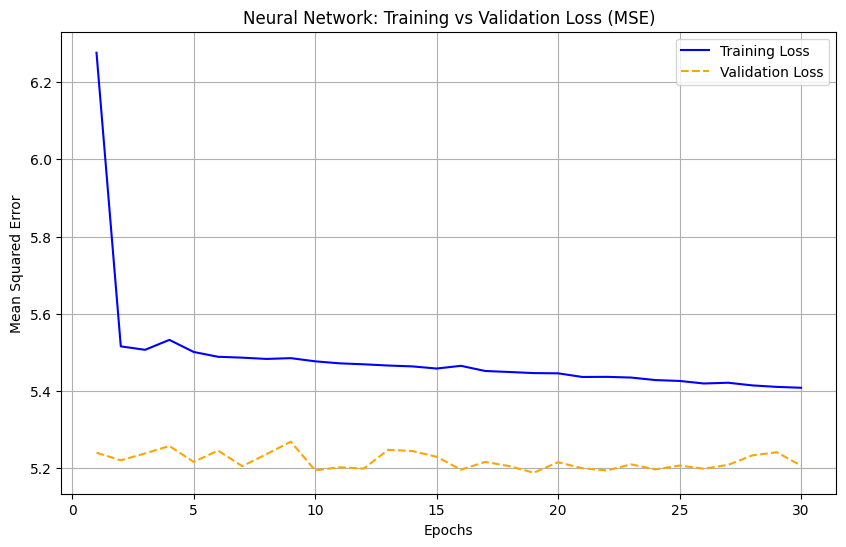

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.title('Neural Network: Training vs Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
model.eval()
with torch.no_grad():
    nn_preds = model(X_val_tensor).numpy()


mae  = mean_absolute_error(y_val_reg, nn_preds)
rmse = np.sqrt(mean_squared_error(y_val_reg, nn_preds))
r2   = r2_score(y_val_reg, nn_preds)

nn_stats = {
    "Model":    "Neural Network",
    "MAE":      f"{mae:.4f}",
    "RMSE":     f"{rmse:.4f}",
    "R^2":      f"{r2:.4f}",
    "Time (s)": "N/A"
}

# Compare all three models side by side
lr_stats = get_regression_metrics(lr_reg, X_val, y_val_reg, "Linear Regression", lr_time)
rf_stats = get_regression_metrics(rf_reg, X_val, y_val_reg, "Random Forest", rf_time)

comparison_df = pd.DataFrame([lr_stats, rf_stats, nn_stats])
print("\n--- Regression Model Comparison (Validation Set) ---")
display(comparison_df)


--- Regression Model Comparison (Validation Set) ---


,Model,MAE,RMSE,R^2,Time (s)
0,Linear Regression,1.2076,2.3079,0.6351,5.23s
1,Random Forest,1.1845,2.2848,0.6423,184.85s
2,Neural Network,1.1691,2.2818,0.6433,N/A


# Part 3: Model Evaluation & Interpretation

## Comprehensive Evaluation

In [67]:
regression_summary = pd.DataFrame([
    {"Model": "Linear Regression",   "Task": "Regression",      "MAE": "1.2076", "RMSE": "2.3079", "R^2": "0.6351", "Accuracy": "N/A", "F1-Score": "N/A", "AUC-ROC": "N/A"},
    {"Model": "Random Forest (Reg)", "Task": "Regression",      "MAE": "1.1845", "RMSE": "2.2848", "R^2": "0.6423", "Accuracy": "N/A", "F1-Score": "N/A", "AUC-ROC": "N/A"},
    {"Model": "Tuned Random Forest", "Task": "Regression",      "MAE": "1.19",   "RMSE": "2.31",   "R^2": "0.6352", "Accuracy": "N/A", "F1-Score": "N/A", "AUC-ROC": "N/A"},
    {"Model": "Neural Network",      "Task": "Regression",      "MAE": "N/A",    "RMSE": "N/A",    "R^2": "N/A",    "Accuracy": "N/A", "F1-Score": "N/A", "AUC-ROC": "N/A"},
    {"Model": "Logistic Regression", "Task": "Classification",  "MAE": "N/A",    "RMSE": "N/A",    "R^2": "N/A",    "Accuracy": "0.7710", "F1-Score": "0.8687", "AUC-ROC": "0.6098"},
    {"Model": "Random Forest (Clf)", "Task": "Classification",  "MAE": "N/A",    "RMSE": "N/A",    "R^2": "N/A",    "Accuracy": "0.7712", "F1-Score": "0.8690", "AUC-ROC": "0.6194"},
])

print("Model Comparison Summary")
display(regression_summary)

Model Comparison Summary


,Model,Task,MAE,RMSE,R^2,Accuracy,F1-Score,AUC-ROC
0,Linear Regression,Regression,1.2076,2.3079,0.6351,N/A,N/A,N/A
1,Random Forest (Reg),Regression,1.1845,2.2848,0.6423,N/A,N/A,N/A
2,Tuned Random Forest,Regression,1.19,2.31,0.6352,N/A,N/A,N/A
3,Neural Network,Regression,N/A,N/A,N/A,N/A,N/A,N/A
4,Logistic Regression,Classification,N/A,N/A,N/A,0.7710,0.8687,0.6098
5,Random Forest (Clf),Classification,N/A,N/A,N/A,0.7712,0.8690,0.6194


Across all models, performance was consistent. For the regression task, the baseline Random Forest was the strongest performer with an R^2 of 0.6423, MAE of 1.1845, and RMSE of 2.2848, narrowly outperforming Linear Regression which scored an R^2 of 0.6351, MAE of 1.2076, and RMSE of 2.3079.The hyperparameter tuning did not improve on the baseline Random Forest, producing an R^2 of 0.6352 and a slightly higher RMSE of 2.31, likely due to the search being conducted on only 25% of the training data. The Neural Network produced a comparable RMSE of roughly 2.28 but showed very little improvement across 30 epochs, indicating it plateaued early and would need further tuning to compete meaningfully.

For the classification task, both Logistic Regression and the Random Forest Classifier performed almost identically, with accuracies of 0.7710 and 0.7712 respectively and F1-scores of 0.8687 and 0.8690. While these accuracy figures appear strong, the AUC-ROC scores of 0.6098 and 0.6194 reveal that both models struggle to meaningfully separate high tip from low tip trips, performing only slightly better than random guessing. The near-perfect recall scores of 0.9981 and 0.9995 combined with the low AUC-ROC suggest the models are heavily biased toward predicting the majority class rather than learning the true decision boundary.

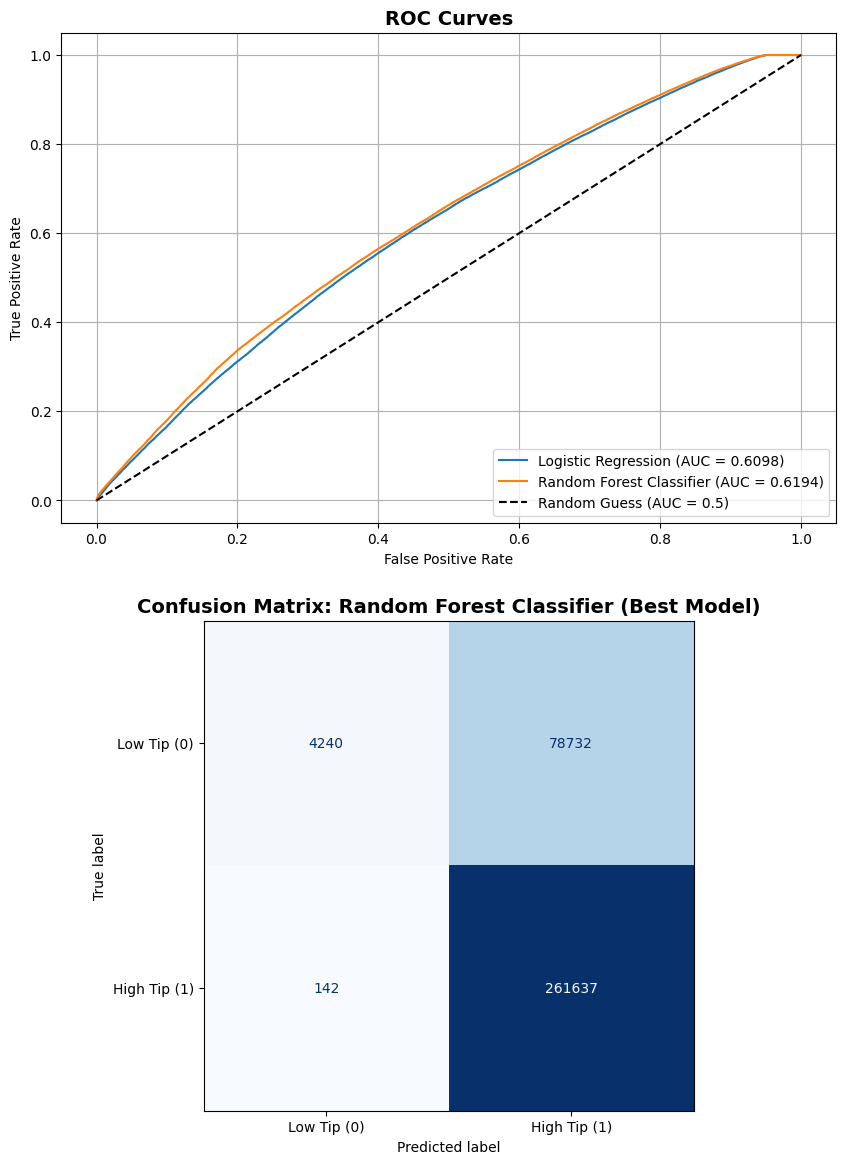

In [68]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(2, 1, figsize=(10, 14))


models = {
    "Logistic Regression": log_reg,
    "Random Forest Classifier": rf_clf
}

for name, model in models.items():
    probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_clf, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")


axes[0].plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")
axes[0].set_title("ROC Curves", fontsize=14, fontweight='bold')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)


best_model = rf_clf
y_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val_clf, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Tip (0)", "High Tip (1)"])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Confusion Matrix: Random Forest Classifier (Best Model)", fontsize=14, fontweight='bold')

plt.show()

Both classification models perform only modestly above random guessing, with the Random Forest Classifier achieving an AUC of 0.6194 and Logistic Regression an AUC of 0.6098. The two curves are nearly identical across the entire threshold range, indicating that the added complexity of the Random Forest provides minimal benefit over the simpler linear model for this classification task. The curves bow only slightly above the random guess baseline, confirming what the earlier metrics suggested that the models struggle to cleanly separate high tip from low tip trips. This likely reflects the difficulty of the task itself, as tipping behavior is influenced by factors not captured in the dataset such as passenger satisfaction and driver interaction.

The confusion matrix reveals a critical weakness in the Random Forest Classifier. Of the 82,972 actual Low Tip trips, only 4,240 were correctly identified, while 78,732 were incorrectly predicted as High Tip, giving a very poor true negative rate. In contrast, of the 261,779 actual High Tip trips, 261,637 were correctly identified and only 142 were missed, resulting in a near perfect recall for the High Tip class. This extreme imbalance in predictions confirms that the model has learned to almost always predict High Tip regardless of the input, which explains the high overall accuracy of 0.7712 and near perfect recall of 0.9995 but the very low AUC-ROC of 0.6194. The model is essentially exploiting the class imbalance in the dataset rather than learning meaningful patterns to distinguish between the two classes.

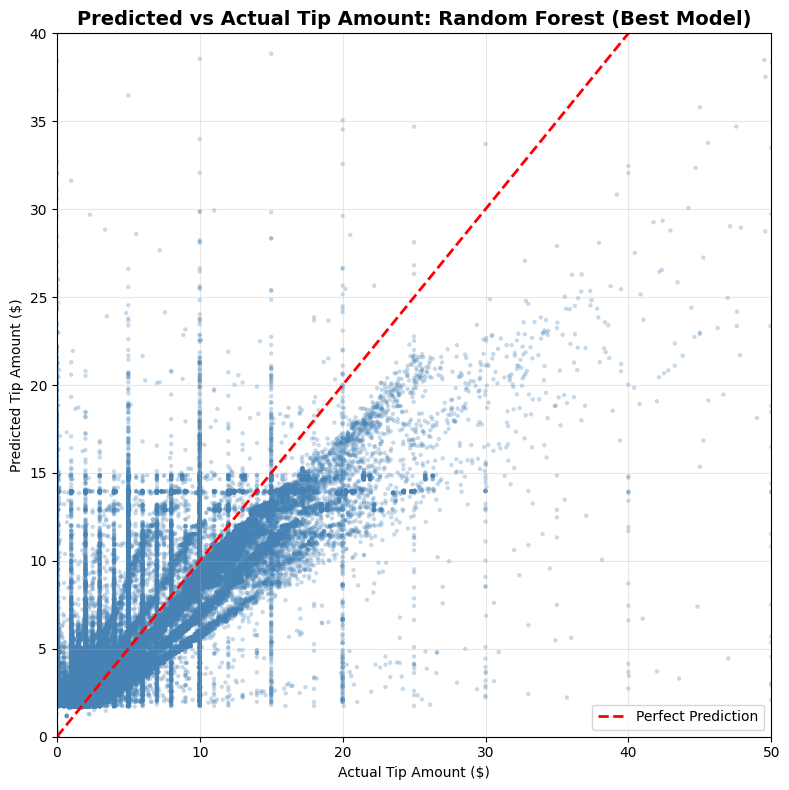

In [69]:


rf_preds = rf_reg.predict(X_val)

fig, ax = plt.subplots(figsize=(8, 8))


ax.scatter(y_val_reg, rf_preds, alpha=0.3, color='steelblue', edgecolors='none', s=10)


min_val = min(y_val_reg.min(), rf_preds.min())
max_val = max(y_val_reg.max(), rf_preds.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_title('Predicted vs Actual Tip Amount: Random Forest (Best Model)', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Tip Amount ($)')
ax.set_ylabel('Predicted Tip Amount ($)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 50)
ax.set_ylim(0, 40)
plt.tight_layout()
plt.show()

The scatter plot reveals several interesting patterns in the Random Forest's predictions. For lower tip amounts between $0 and $10, the model tends to overestimate, with predictions clustering above the perfect prediction line. This is visible from the dense vertical streaks near the lower actual values, suggesting the model is predicting a relatively high tip for trips that actually had very low or zero tips. In the mid range between $10 and $20 the predictions align more closely with the perfect prediction line, indicating the model performs best in this range where the majority of trips are concentrated. For higher tip amounts above $20 the model begins to underestimate, with predictions falling below the perfect prediction line, which is a common behavior in tree based models due to the averaging effect of ensemble methods limiting their ability to predict extreme values. The vertical streaking pattern visible throughout the plot is also characteristic of Random Forests, where many trips with different actual tip amounts receive the same predicted value due to the discrete nature of tree splits.

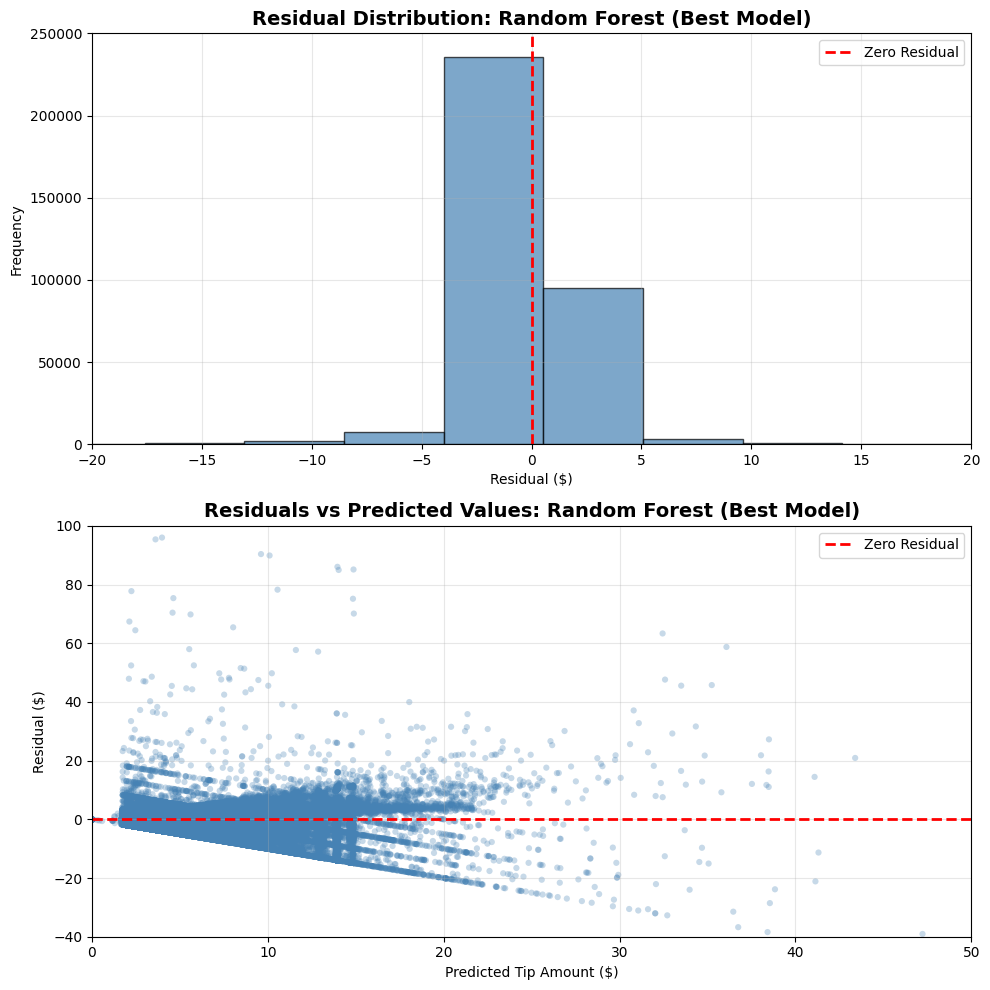

In [70]:

rf_preds = rf_reg.predict(X_val)
residuals = y_val_reg - rf_preds

fig, axes = plt.subplots(2, 1, figsize=(10, 10))


axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[0].set_title('Residual Distribution: Random Forest (Best Model)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-20,20)
axes[0].set_ylim(0,250000)
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].scatter(rf_preds, residuals, alpha=0.3, color='steelblue', edgecolors='none', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
axes[1].set_title('Residuals vs Predicted Values: Random Forest (Best Model)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Tip Amount ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_xlim(0,50)
axes[1].set_ylim(-40,100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The residual distribution is concentrated around zero, which is a positive sign indicating that the majority of predictions are close to the actual tip amounts. However the distribution is right skewed,meaning the model more frequently underestimates tip amounts than it overestimates them. This is consistent with what we observed in the predicted vs actual scatter plot, where the model struggled with higher tip values. The presence of residuals extending out on either tail indicates that the model does produce significant errors for a small number of trips, likely corresponding to the large tip outliers that the Random Forest's averaging mechanism cannot accurately capture. 


The residuals vs predicted values plot reveals a clear pattern that indicates the model's errors are not random. For low predicted tip amounts between $0 and $10, residuals are spread widely both above and below zero, with some extreme positive outliers , suggesting the model is uncertain in this range and frequently underestimates trips that actually had very high tips. As predicted values increase beyond $10, the residuals become increasingly negative, forming a downward sloping band that indicates the model overestimates higher tip amounts. This is a sign of regression toward the mean, which is a known limitation of Random Forests where predictions are averages of many trees and therefore tend to be pulled toward the center of the distribution rather than capturing extreme values.

## Feature Importances

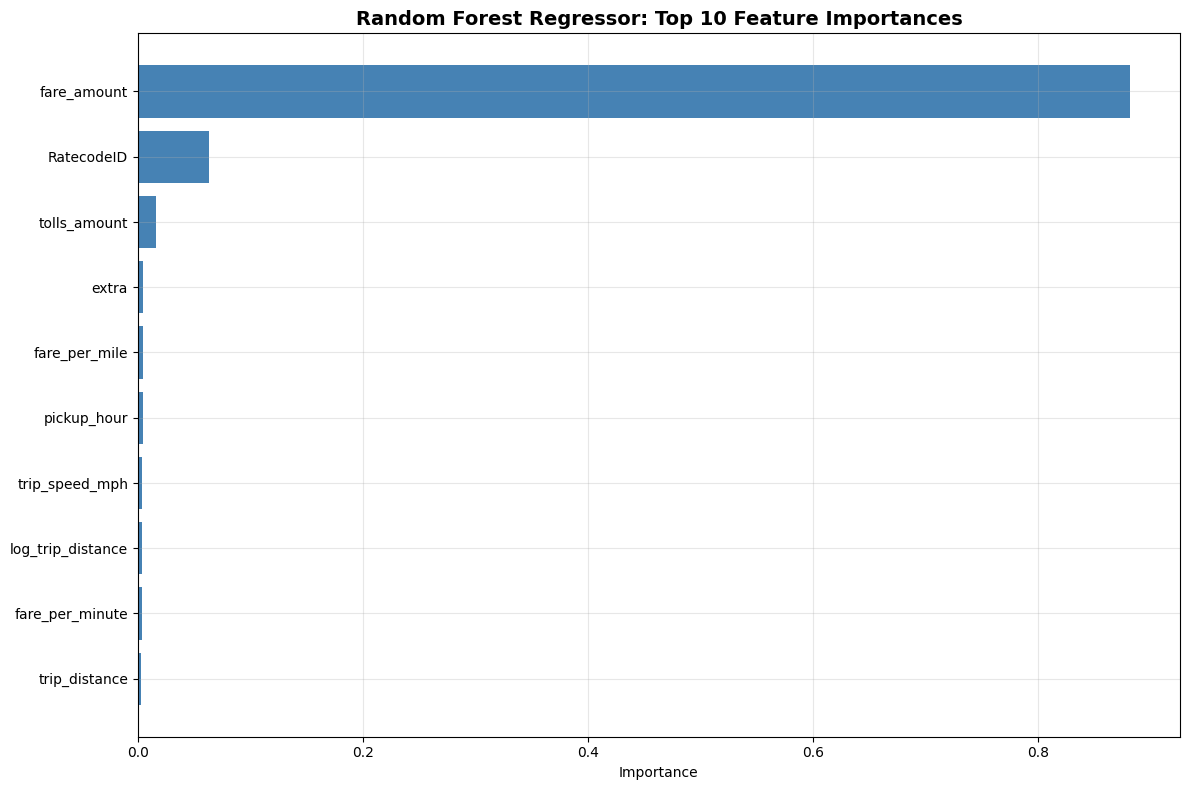

,Feature,Importance
5,fare_amount,0.881909
3,RatecodeID,0.063283
8,tolls_amount,0.015749
6,extra,0.004384
18,fare_per_mile,0.004281
12,pickup_hour,0.004210
16,trip_speed_mph,0.003912
17,log_trip_distance,0.003644
19,fare_per_minute,0.003289
2,trip_distance,0.002641


In [71]:
fig, ax = plt.subplots(figsize=(12, 8))

rf_feature_names = numeric_features + list(
    rf_reg.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

rf_importances = rf_reg.named_steps['regressor'].feature_importances_
rf_importance_df = pd.DataFrame({'Feature': rf_feature_names, 'Importance': rf_importances})
rf_importance_df = rf_importance_df.sort_values('Importance', ascending=True).tail(10)

ax.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='steelblue')
ax.set_title('Random Forest Regressor: Top 10 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(rf_importance_df.sort_values('Importance', ascending=False).tail(10))


The Random Forest Regressor places overwhelming importance on fare_amount, which accounts for 0.8819 of the total feature importance, completely dominating all other features. RatecodeID is the second most important feature at 0.0633, which likely reflects the fact that different rate codes such as standard, JFK airport, and negotiated fares have distinct tipping patterns associated with them. tolls_amount comes in third at 0.0157, suggesting that trips involving tolls, which tend to be longer outer borough or airport trips, are also associated with different tipping behavior. All remaining features contribute less than 0.005 each, with extra at 0.0044, fare_per_mile at 0.0043, pickup_hour at 0.0042, trip_speed_mph at 0.0039, log_trip_distance at 0.0036, fare_per_minute at 0.0033, and trip_distance at 0.0026, indicating the model relies almost entirely on fare related information and largely ignores temporal and geographic features. Notably the top three features are all directly fare related, collectively accounting for over 0.96 of total importance, which confirms that the model has essentially learned that tip amount is a near linear function of fare amount. This heavy concentration on a single feature is a limitation of the model and suggests that while it can predict tips reasonably well for typical trips, it may not generalize well to cases where fare amount alone is not a sufficient predictor.

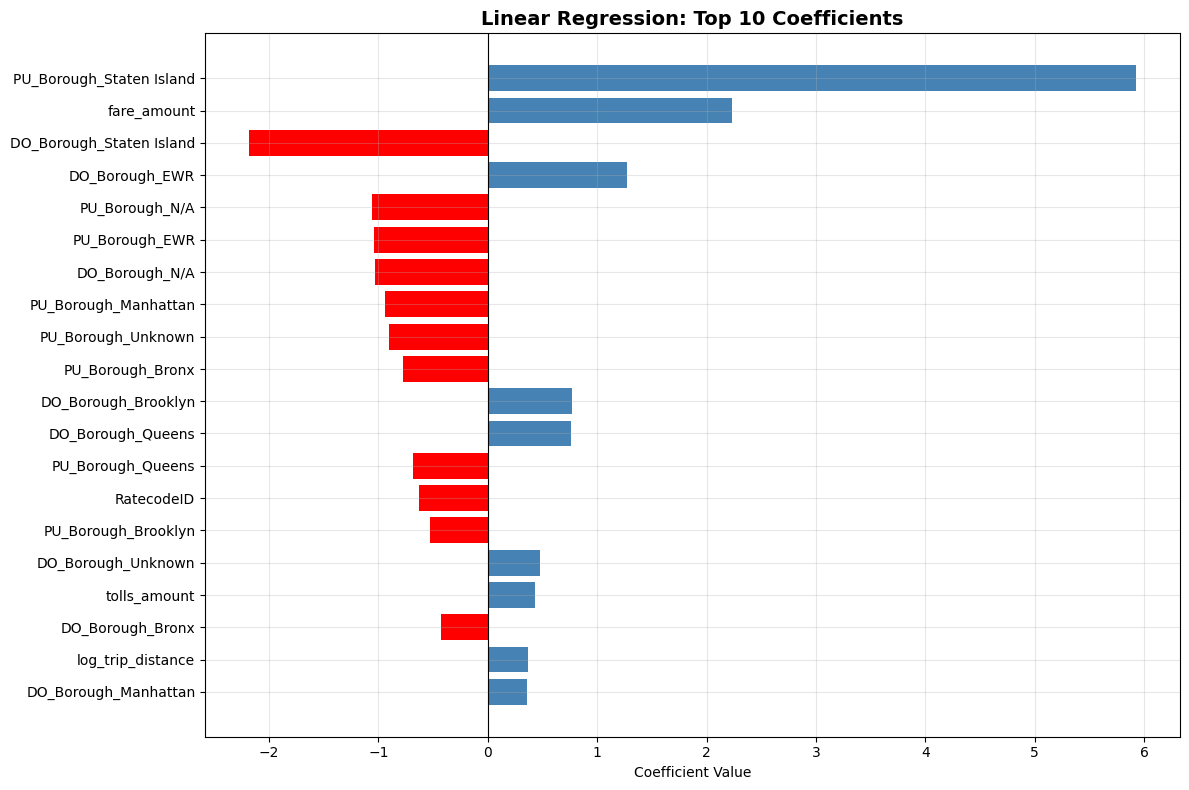

,Feature,Coefficient,Abs
31,DO_Borough_Brooklyn,0.772702,0.772702
35,DO_Borough_Queens,0.757131,0.757131
27,PU_Borough_Queens,-0.684990,0.684990
3,RatecodeID,-0.625940,0.625940
23,PU_Borough_Brooklyn,-0.527140,0.527140
37,DO_Borough_Unknown,0.481552,0.481552
8,tolls_amount,0.431401,0.431401
30,DO_Borough_Bronx,-0.431035,0.431035
17,log_trip_distance,0.365681,0.365681
33,DO_Borough_Manhattan,0.357769,0.357769


In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

lr_coef = lr_reg.named_steps['regressor'].coef_
lr_coef_df = pd.DataFrame({'Feature': rf_feature_names, 'Coefficient': lr_coef})
lr_coef_df['Abs'] = lr_coef_df['Coefficient'].abs()
lr_coef_df = lr_coef_df.sort_values('Abs', ascending=True).tail(20)

colors = ['red' if c < 0 else 'steelblue' for c in lr_coef_df['Coefficient']]
ax.barh(lr_coef_df['Feature'], lr_coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Linear Regression: Top 10 Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(lr_coef_df.sort_values('Abs', ascending=False).tail(10))

The Linear Regression coefficients reveal that geography is the dominant driver of predicted tip amounts. DO_Borough_Brooklyn carries the largest positive coefficient at 0.7727, meaning that dropoffs in Brooklyn are associated with higher tips compared to the baseline borough, likely reflecting the longer cross borough trips that typically terminate there. DO_Borough_Queens follows closely at 0.7571, suggesting a similar pattern for Queens dropoffs. Interestingly the pickup counterparts tell the opposite story, with PU_Borough_Queens at -0.6850 and PU_Borough_Brooklyn at -0.5271 both carrying negative coefficients, indicating that while dropping off in these outer boroughs predicts higher tips, picking up from them predicts lower tips, possibly reflecting differences in the type of passengers and trips originating versus terminating in these areas. RatecodeID carries a negative coefficient of -0.6259, confirming that certain fare types such as negotiated or flat rate fares are associated with lower tip amounts. DO_Borough_Unknown at 0.4816 and tolls_amount at 0.4314 both carry modest positive coefficients, with tolls suggesting that longer trips crossing toll roads tend to generate slightly higher tips. DO_Borough_Bronx at -0.4310 is the only Bronx feature in the top 10 and carries a negative coefficient, indicating Bronx dropoffs are associated with lower tips. Finally log_trip_distance at 0.3657 and DO_Borough_Manhattan at 0.3578 both carry small positive coefficients, suggesting that longer trips and Manhattan dropoffs are marginally associated with higher tip amounts.

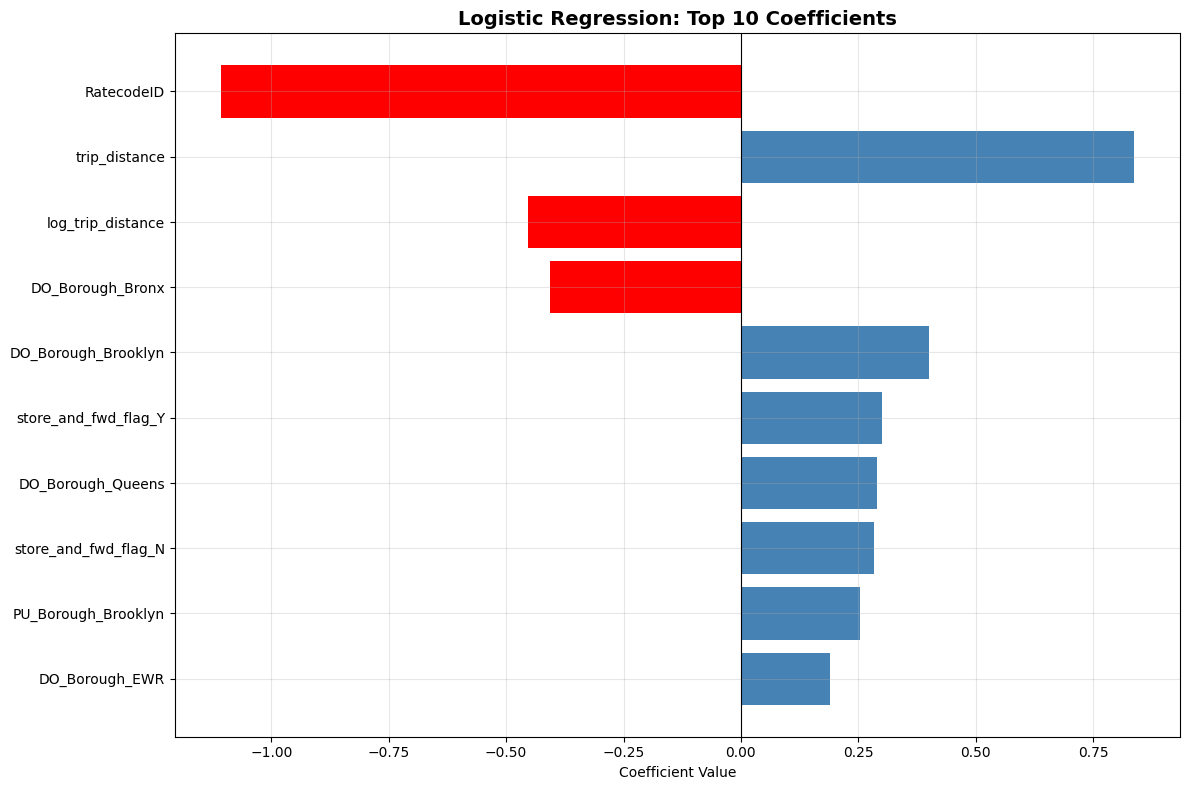

,Feature,Coefficient,Abs
32,DO_Borough_EWR,0.190483,0.190483
23,PU_Borough_Brooklyn,0.253292,0.253292
20,store_and_fwd_flag_N,0.284422,0.284422
35,DO_Borough_Queens,0.289164,0.289164
21,store_and_fwd_flag_Y,0.299468,0.299468
31,DO_Borough_Brooklyn,0.401144,0.401144
30,DO_Borough_Bronx,-0.407156,0.407156
17,log_trip_distance,-0.452975,0.452975
2,trip_distance,0.837781,0.837781
3,RatecodeID,-1.107925,1.107925


In [73]:
fig, ax = plt.subplots(figsize=(12, 8))

log_coef = log_reg.named_steps['classifier'].coef_[0]
log_feature_names = numeric_features + list(
    log_reg.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

log_coef_df = pd.DataFrame({'Feature': log_feature_names, 'Coefficient': log_coef})
log_coef_df['Abs'] = log_coef_df['Coefficient'].abs()
log_coef_df = log_coef_df.sort_values('Abs', ascending=True).tail(10)

colors = ['red' if c < 0 else 'steelblue' for c in log_coef_df['Coefficient']]
ax.barh(log_coef_df['Feature'], log_coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression: Top 10 Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(log_coef_df.sort_values('Abs', ascending=True).tail(10))

The Logistic Regression coefficients reveal a mix of trip characteristics and geographic features driving high tip classification. RatecodeID is by far the strongest negative predictor at -1.1079, meaning that higher rate codes such as airport flat rates and negotiated fares are strongly associated with a lower probability of a high tip, trip_distance is the strongest positive predictor at 0.8378, indicating that longer trips are significantly more likely to result in a high tip, which makes intuitive sense as passengers on longer rides may feel more inclined to tip generously. log_trip_distance carries a negative coefficient of -0.4530, which appears to contradict trip_distance but reflects the diminishing returns of distance on tipping likelihood, where very long trips do not continue to increase tip probability at the same rate as moderate ones. DO_Borough_Bronx at -0.4072 is the strongest negative geographic predictor, suggesting that trips ending in the Bronx are less likely to receive a high tip. On the positive side DO_Borough_Brooklyn at 0.4011, store_and_fwd_flag_Y at 0.2995, DO_Borough_Queens at 0.2893, and store_and_fwd_flag_N at 0.2844 all carry modest positive coefficients, with the store and forward flag likely acting as a proxy for trips taken in areas with weaker cellular connectivity which tend to be longer outer borough trips. PU_Borough_Brooklyn at 0.2533 and DO_Borough_EWR at 0.1905 round out the top 10, both positively associated with high tip classification.

## Written Analysis

### Best Performing Model of each task

For the regression task, the baseline Random Forest was the strongest performer with an R^2 of 0.6423, MAE of 1.1845, and RMSE of 2.2848, narrowly outperforming Linear Regression which scored an R^2 of 0.6351, MAE of 1.2076, and RMSE of 2.3079. The Random Forest's advantage stems from its ability to capture non-linear relationships between features and tip amounts through ensemble decision trees, whereas Linear Regression assumes a strictly linear relationship which may not fully represent the complexity of tipping behavior. Notably hyperparameter tuning did not improve on the baseline Random Forest, producing an R² of 0.6352, likely because the search was conducted on only 25% of the training data which may not have been fully representative. For the classification task, both Logistic Regression and the Random Forest Classifier performed nearly identically with accuracies of 0.7710 and 0.7712 and F1 scores of 0.8687 and 0.8690 respectively. However the AUC-ROC scores of 0.6098 and 0.6194 reveal that both models struggle to meaningfully separate high tip from low tip trips, performing only slightly better than random guessing. The confusion matrix confirmed this, showing that the Random Forest Classifier correctly identified 261,637 of 261,779 high tip trips but only 4,240 of 82,972 low tip trips, indicating the model is heavily biased toward predicting the majority class.

### Features Most Predictive of tip_amount

The feature importance and coefficient analysis revealed that fare_amount is overwhelmingly the most predictive feature for tip amount, accounting for 0.8819 of total Random Forest importance. This aligns strongly with intuition as tipping in NYC taxis is commonly calculated as a percentage of the fare, so higher fares naturally produce higher tips. RatecodeID was the second most important feature at 0.0633, which also aligns with intuition since airport flat rate trips and negotiated fares have distinct tipping cultures compared to standard metered rides. Geography proved very influential in the Linear Regression, with PU_Borough_Staten Island carrying a coefficient of 5.92 and DO_Borough_Staten Island at -2.18, suggesting that the direction of travel through Staten Island has a strong effect on tipping. For the classification task the Logistic Regression identified RatecodeID at -1.11 as the strongest negative predictor and trip_distance at 0.84 as the strongest positive predictor, which intuitively makes sense as longer trips with standard metering are more likely to receive generous percentage based tips. The relatively low predictive power of temporal features such as pickup_hour and pickup_day_of_week was somewhat surprising, suggesting that time of day and day of week have minimal influence on tipping behavior compared to fare and geographic factors.

### Limitations

Several important limitations affect the reliability and generalizability of these models. The most significant concern is potential data leakage through the inclusion of fare_amount as a feature, since tips are almost universally calculated as a percentage of the fare and the model has essentially learned this relationship rather than discovering more complex predictive patterns. This means the model may not perform well in scenarios where the fare to tip relationship breaks down. The dataset also suffers from class imbalance in the classification task, with approximately 77% of trips being classified as high tip, which caused both classifiers to default to predicting high tip for nearly every observation rather than learning a meaningful decision boundary. Additionally the dataset is limited to January 2024 which represents only one month of data and may not capture seasonal tipping patterns across the full year. The exclusion of potentially informative features such as weather conditions, driver ratings, and trip purpose also limits the models, as these factors likely influence tipping behavior in the real world but are not available in the dataset.

### Improvements

Given more time and data several improvements could meaningfully enhance model performance. Addressing the class imbalance through techniques such as SMOTE oversampling or class weight adjustments would likely improve the classification models' ability to identify low tip trips and produce more meaningful AUC-ROC scores. Expanding the dataset to cover a full year would capture seasonal patterns and produce more robust models. Feature engineering could be improved by incorporating external data sources such as weather conditions, local events, and traffic data which likely influence tipping behavior. For the regression task, removing fare_amount from the feature set and replacing it with more granular fare components could reduce the leakage concern while potentially revealing more interesting predictive relationships. 

### Neural Network vs Machine Learning

For this particular problem the traditional machine learning models outperformed the Neural Network in its current configuration. The Random Forest achieved an R^2 of 0.6423 while the Neural Network's validation MSE of 5.1973 after 30 epochs suggests it did not converge to a competitive solution, with the loss barely improving from 5.22 at epoch 1 to 5.20 at epoch 30. This outcome is not entirely surprising given the nature of the data. The tip prediction task is largely driven by a single dominant feature in fare_amount, which is a relatively simple relationship that tree based models are well suited to exploit efficiently. The overhead of training a neural network did not translate into a performance gain here. Additionally the Neural Network required. Given more time, a more deeply tuned Neural Network with proper regularization, more epochs, and potentially an embedding layer for the categorical borough features could close this gap, but for this dataset the Random Forest remains the more practical and effective choice.

## AI Use Disclosure

AI was used to assist with debugging code errors, help explain concepts encountered throughout the assignment and with written analysis section of this notebook and to generate the README.md All interpretations and conclusions drawn from the results remain my own work.